In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
data["TotalCharges"]=pd.to_numeric(data["TotalCharges"], errors="coerce")

In [7]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())
cat_cols = data.select_dtypes(include="object").columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [14]:
num_columns = data.select_dtypes(include=['int64','float64'])
for col in num_columns:
    data[col] = data[col].fillna(data[col].mean())

In [20]:
outlier_info = {}

for col in num_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outlier_info[col] = outliers.shape[0]
    data[col] = np.where(data[col] < lower, lower, data[col])
    data[col] = np.where(data[col] > upper, upper, data[col])

    print(f"{col}: {outliers.shape[0]} outliers")

SeniorCitizen: 0 outliers
tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


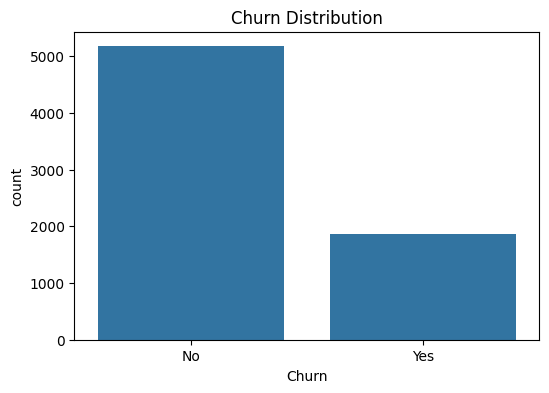

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

print(data["Churn"].value_counts())

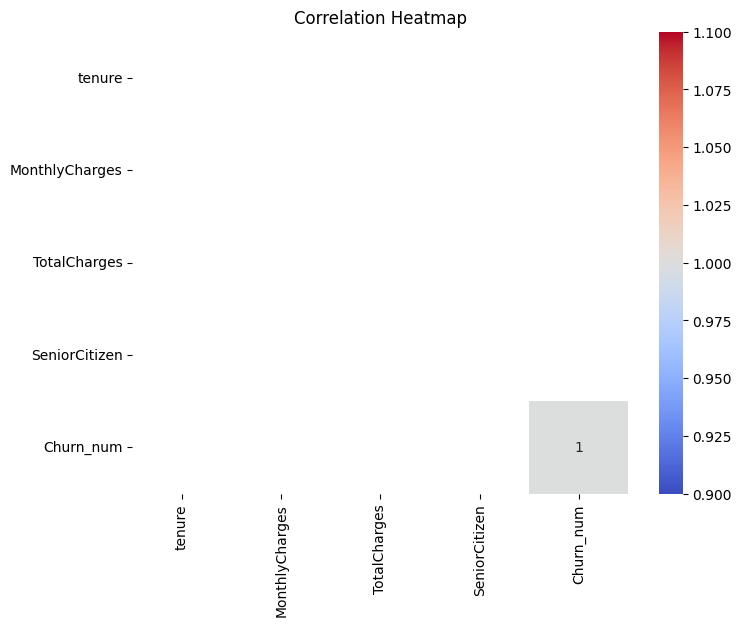

In [24]:
data["Churn_num"] = data["Churn"].map({"Yes":1, "No":0})

corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_num"]

plt.figure(figsize=(8,6))
sns.heatmap(data[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


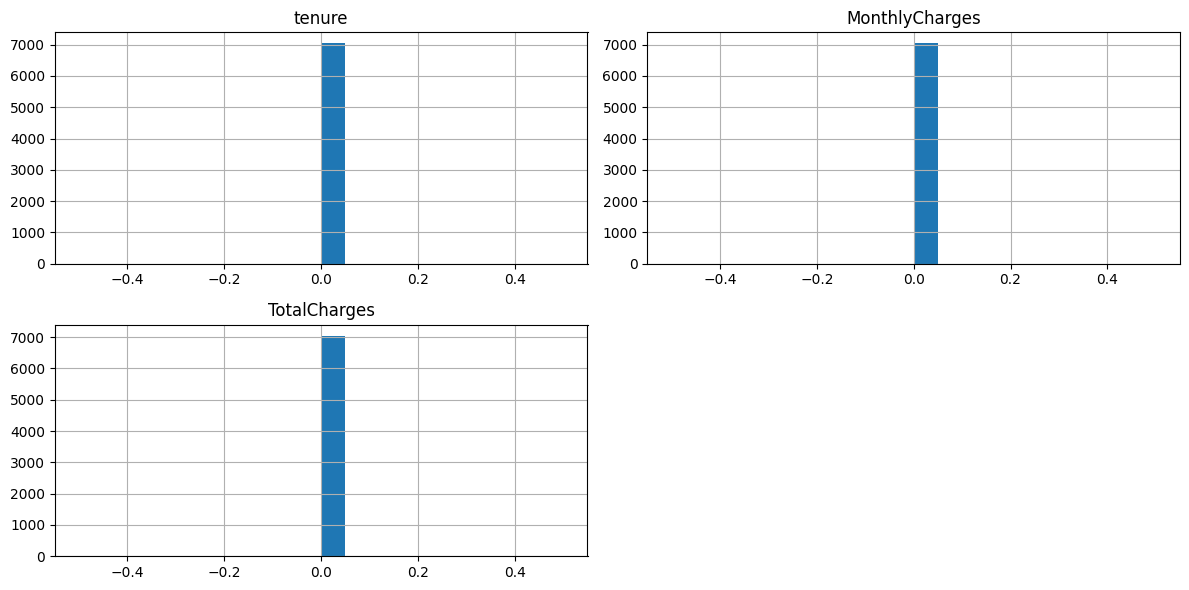

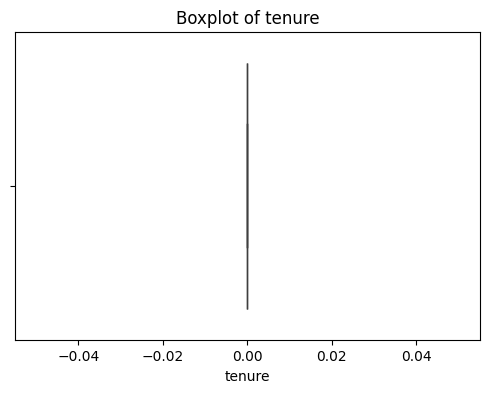

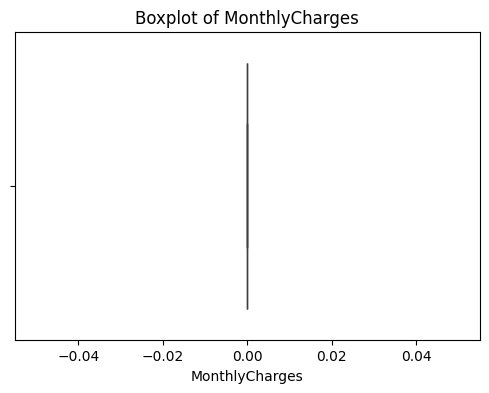

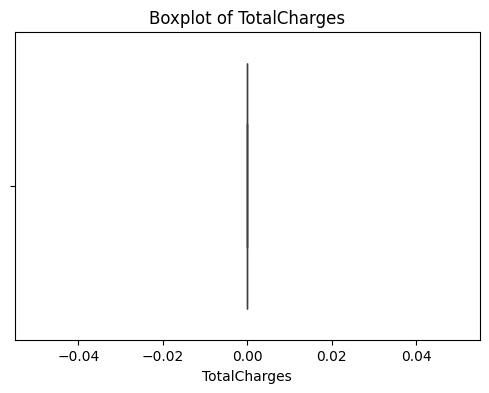

In [25]:
data[["tenure","MonthlyCharges","TotalCharges"]].hist(figsize=(12,6), bins=20)
plt.tight_layout()
plt.show()

for col in ["tenure","MonthlyCharges","TotalCharges"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

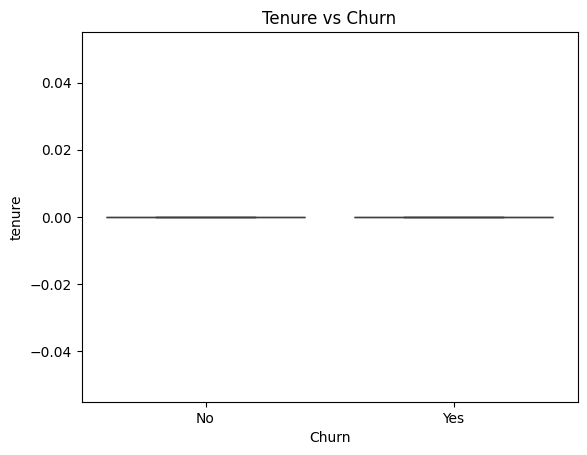

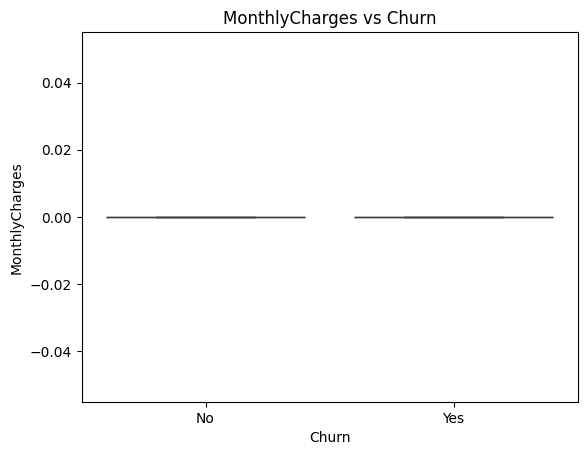

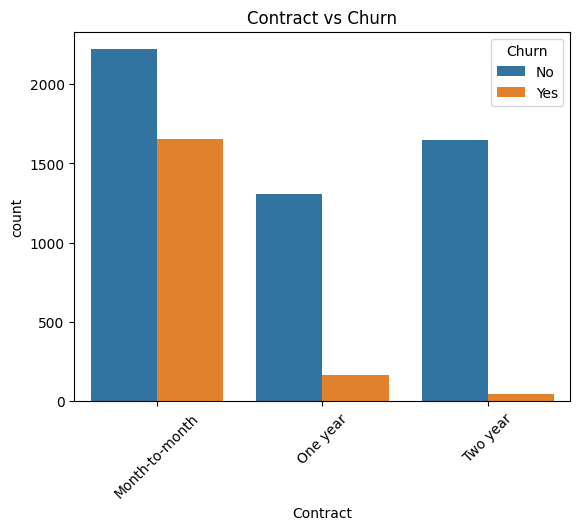

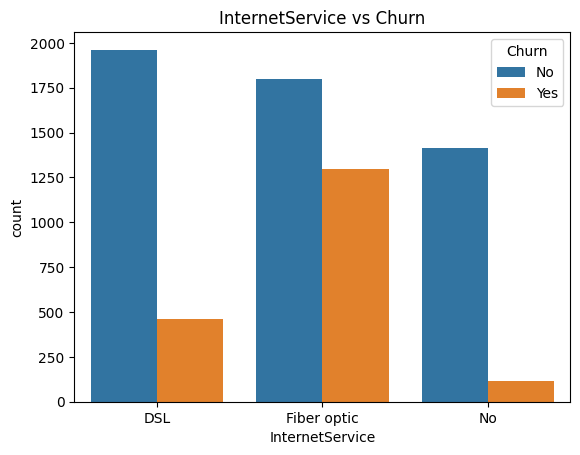

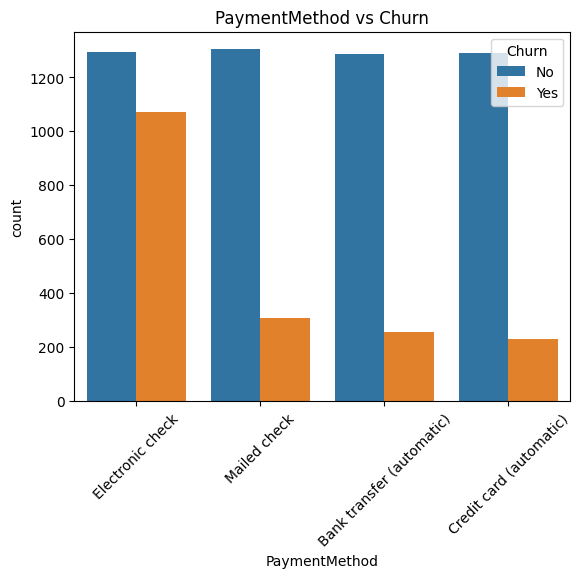

In [27]:
# 1 Tenure vs Churn
sns.boxplot(x="Churn", y="tenure", data=data)
plt.title("Tenure vs Churn")
plt.show()

# 2 MonthlyCharges vs Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=data)
plt.title("MonthlyCharges vs Churn")
plt.show()

# 3 Contract vs Churn
sns.countplot(x="Contract", hue="Churn", data=data)
plt.title("Contract vs Churn")
plt.xticks(rotation=45)
plt.show()

# 4 InternetService vs Churn
sns.countplot(x="InternetService", hue="Churn", data=data)
plt.title("InternetService vs Churn")
plt.show()

# 5 PaymentMethod vs Churn
sns.countplot(x="PaymentMethod", hue="Churn", data=data)
plt.title("PaymentMethod vs Churn")
plt.xticks(rotation=45)
plt.show()


In [28]:
print("Business Insights")
print("1. Customers with month-to-month contracts churn the most.")
print("2. New customers with low tenure are more likely to leave.")
print("3. Customers paying high monthly charges show higher churn.")
print("4. Long-term contract users are more loyal.")
print("5. Certain payment methods indicate higher churn risk.")

Business Insights
1. Customers with month-to-month contracts churn the most.
2. New customers with low tenure are more likely to leave.
3. Customers paying high monthly charges show higher churn.
4. Long-term contract users are more loyal.
5. Certain payment methods indicate higher churn risk.
